# Grid Explorer - MIST Isochrone Visualizer

Deliverable: interactive slider notebook showing how isochrone tracks shift with age and metallicity, built on the same MIST grid and interpolation setup used in the main pipeline.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.widgets import Slider
import pandas as pd
from isochrones.mist import MIST_Isochrone
from IPython.display import display

mist = MIST_Isochrone()

# plot style 
plt.rcParams.update({
    "figure.facecolor":  "#0d0d14",
    "axes.facecolor":    "#0d0d14",
    "axes.edgecolor":    "#3a3a55",
    "axes.labelcolor":   "#e0e0f0",
    "axes.labelsize":    12,
    "axes.titlesize":    13,
    "axes.titlecolor":   "#e0e0f0",
    "xtick.color":       "#8888aa",
    "ytick.color":       "#8888aa",
    "grid.color":        "#1e1e30",
    "grid.linewidth":    0.8,
    "text.color":        "#e0e0f0",
    "font.family":       "serif",
    "font.serif":        ["Palatino Linotype", "Palatino", "Georgia", "DejaVu Serif"],
    "legend.facecolor":  "#13131f",
    "legend.edgecolor":  "#3a3a55",
})

PyMultiNest not imported.  MultiNest fits will not work.


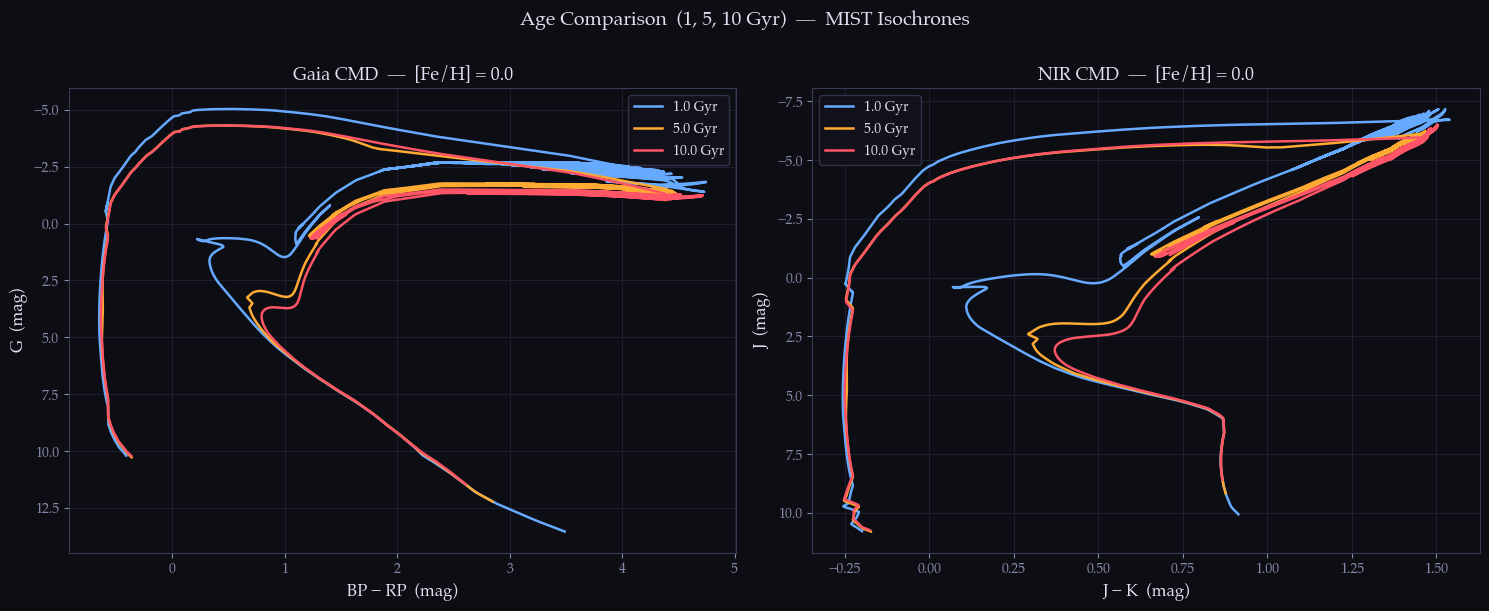

In [2]:
# Static comparison plots (deliverable figures)

# 2a: Age comparison (1 Gyr vs 5 Gyr vs 10 Gyr)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor("#0d0d14")

ages_to_plot = [1.0, 5.0, 10.0]
age_colors   = ["#66aaff", "#ffaa33", "#ff5566"]
feh_fixed    = 0.0

for ax in axes:
    ax.set_facecolor("#0d0d14")
    for spine in ax.spines.values():
        spine.set_edgecolor("#3a3a55")
    ax.tick_params(colors="#8888aa")
    ax.grid(True, color="#1e1e30", linewidth=0.8)

for age, color in zip(ages_to_plot, age_colors):
    iso = mist.isochrone(np.log10(age * 1e9), feh_fixed)
    if iso.empty:
        continue
    iso = iso.sort_values("initial_mass")

    # left: CMD (color-magnitude diagram) — BP-RP vs G
    axes[0].plot(
        iso["BP_mag"] - iso["RP_mag"], iso["G_mag"],
        color=color, lw=1.8, label=f"{age} Gyr"
    )

    # right: NIR CMD — J-K vs J
    axes[1].plot(
        iso["J_mag"] - iso["K_mag"], iso["J_mag"],
        color=color, lw=1.8, label=f"{age} Gyr"
    )

axes[0].invert_yaxis()
axes[0].set_xlabel("BP − RP  (mag)")
axes[0].set_ylabel("G  (mag)")
axes[0].set_title(f"Gaia CMD  —  [Fe/H] = {feh_fixed}")
axes[0].legend(fontsize=10, labelcolor="#e0e0f0")

axes[1].invert_yaxis()
axes[1].set_xlabel("J − K  (mag)")
axes[1].set_ylabel("J  (mag)")
axes[1].set_title(f"NIR CMD  —  [Fe/H] = {feh_fixed}")
axes[1].legend(fontsize=10, labelcolor="#e0e0f0")

fig.suptitle("Age Comparison  (1, 5, 10 Gyr)  —  MIST Isochrones",
             fontsize=14, color="#e0e0f0", y=1.01, fontfamily="serif")
plt.tight_layout()
plt.savefig("grid_explorer_age_comparison.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

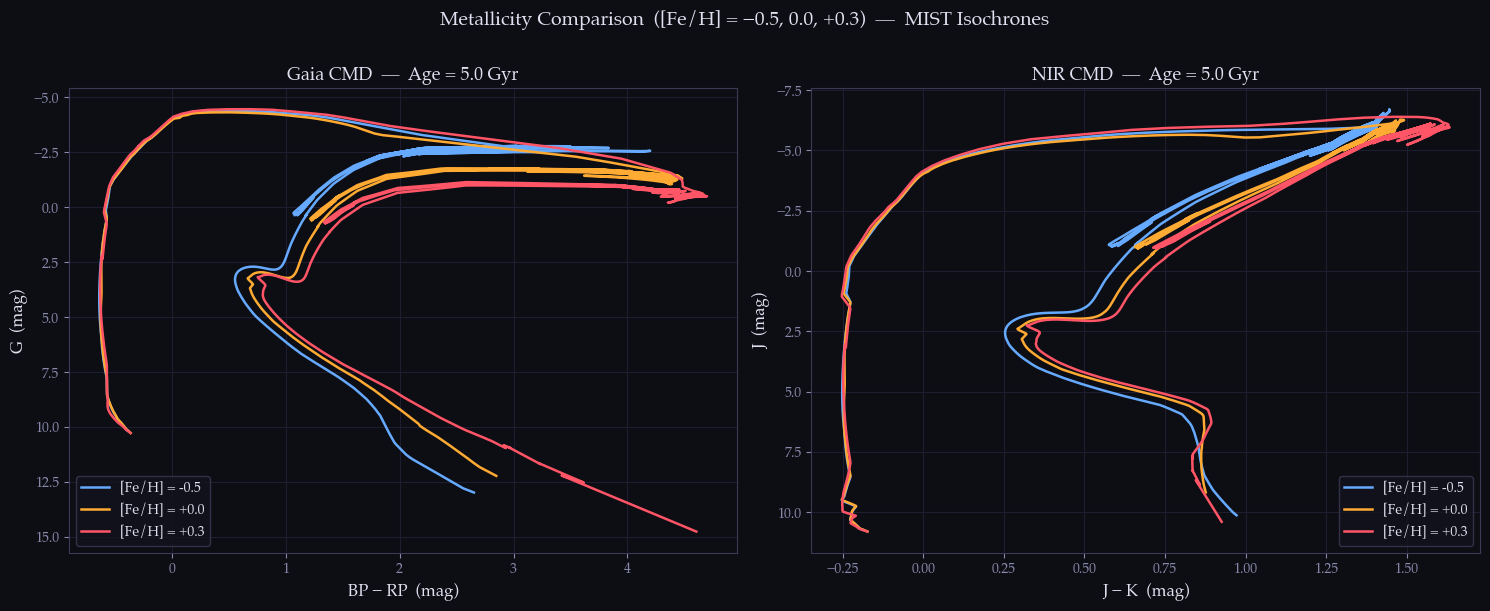

In [3]:
# 2b: Metallicity comparison ([Fe/H] = -0.5, 0.0, +0.3) --
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor("#0d0d14")

fehs_to_plot = [-0.5, 0.0, 0.3]
feh_colors   = ["#66aaff", "#ffaa33", "#ff5566"]
age_fixed    = 5.0   # Gyr

for ax in axes:
    ax.set_facecolor("#0d0d14")
    for spine in ax.spines.values():
        spine.set_edgecolor("#3a3a55")
    ax.tick_params(colors="#8888aa")
    ax.grid(True, color="#1e1e30", linewidth=0.8)

for feh, color in zip(fehs_to_plot, feh_colors):
    iso = mist.isochrone(np.log10(age_fixed * 1e9), feh)
    if iso.empty:
        continue
    iso = iso.sort_values("initial_mass")

    axes[0].plot(
        iso["BP_mag"] - iso["RP_mag"], iso["G_mag"],
        color=color, lw=1.8, label=f"[Fe/H] = {feh:+.1f}"
    )
    axes[1].plot(
        iso["J_mag"] - iso["K_mag"], iso["J_mag"],
        color=color, lw=1.8, label=f"[Fe/H] = {feh:+.1f}"
    )

axes[0].invert_yaxis()
axes[0].set_xlabel("BP − RP  (mag)")
axes[0].set_ylabel("G  (mag)")
axes[0].set_title(f"Gaia CMD  —  Age = {age_fixed} Gyr")
axes[0].legend(fontsize=10, labelcolor="#e0e0f0")

axes[1].invert_yaxis()
axes[1].set_xlabel("J − K  (mag)")
axes[1].set_ylabel("J  (mag)")
axes[1].set_title(f"NIR CMD  —  Age = {age_fixed} Gyr")
axes[1].legend(fontsize=10, labelcolor="#e0e0f0")

fig.suptitle("Metallicity Comparison  ([Fe/H] = −0.5, 0.0, +0.3)  —  MIST Isochrones",
             fontsize=14, color="#e0e0f0", y=1.01, fontfamily="serif")
plt.tight_layout()
plt.savefig("grid_explorer_feh_comparison.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()



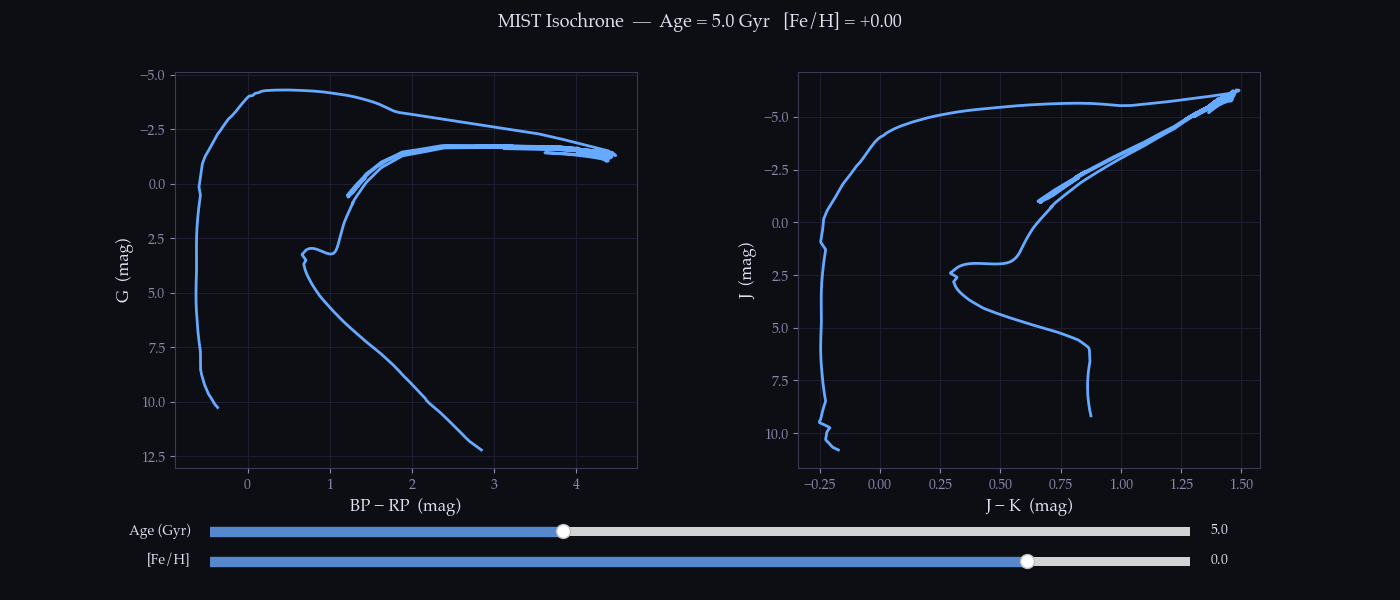

In [4]:
# Interactive slider (age AND metallicity)

%matplotlib widget

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor("#0d0d14")
fig.subplots_adjust(bottom=0.22, wspace=0.35)

for ax in axes:
    ax.set_facecolor("#0d0d14")
    for spine in ax.spines.values():
        spine.set_edgecolor("#3a3a55")
    ax.tick_params(colors="#8888aa")
    ax.grid(True, color="#1e1e30", linewidth=0.8)

# initial isochrone
init_age = 5.0
init_feh = 0.0

def get_iso(age_gyr, feh):
    iso = mist.isochrone(np.log10(age_gyr * 1e9), feh)
    if iso.empty:
        return None
    return iso.sort_values("initial_mass")

iso0 = get_iso(init_age, init_feh)

line_cmd, = axes[0].plot(
    iso0["BP_mag"] - iso0["RP_mag"], iso0["G_mag"],
    color="#66aaff", lw=2.0
)
line_nir, = axes[1].plot(
    iso0["J_mag"] - iso0["K_mag"], iso0["J_mag"],
    color="#66aaff", lw=2.0
)

axes[0].invert_yaxis()
axes[0].set_xlabel("BP − RP  (mag)")
axes[0].set_ylabel("G  (mag)")
axes[1].invert_yaxis()
axes[1].set_xlabel("J − K  (mag)")
axes[1].set_ylabel("J  (mag)")

title = fig.suptitle(
    f"MIST Isochrone  —  Age = {init_age:.1f} Gyr   [Fe/H] = {init_feh:+.2f}",
    fontsize=13, color="#e0e0f0", fontfamily="serif"
)

# sliders 
ax_age = fig.add_axes([0.15, 0.10, 0.70, 0.03], facecolor="#13131f")
ax_feh = fig.add_axes([0.15, 0.05, 0.70, 0.03], facecolor="#13131f")

slider_age = Slider(ax_age, "Age (Gyr)", 0.5, 13.0,
                    valinit=init_age, color="#5588cc")
slider_feh = Slider(ax_feh, "[Fe/H]",   -2.5,  0.5,
                    valinit=init_feh, color="#5588cc")

for sl in [slider_age, slider_feh]:
    sl.label.set_color("#e0e0f0")
    sl.valtext.set_color("#e0e0f0")

def update(val):
    age = slider_age.val
    feh = slider_feh.val
    iso = get_iso(age, feh)
    if iso is None:
        return

    line_cmd.set_xdata(iso["BP_mag"] - iso["RP_mag"])
    line_cmd.set_ydata(iso["G_mag"])
    line_nir.set_xdata(iso["J_mag"] - iso["K_mag"])
    line_nir.set_ydata(iso["J_mag"])

    # rescale axes to new data
    for ax, xdata, ydata in [
        (axes[0], iso["BP_mag"] - iso["RP_mag"], iso["G_mag"]),
        (axes[1], iso["J_mag"]  - iso["K_mag"],  iso["J_mag"])
    ]:
        ax.set_xlim(xdata.min() - 0.1, xdata.max() + 0.1)
        ax.set_ylim(ydata.max() + 0.5, ydata.min() - 0.5)  # inverted

    title.set_text(
        f"MIST Isochrone  —  Age = {age:.1f} Gyr   [Fe/H] = {feh:+.2f}"
    )
    fig.canvas.draw_idle()

slider_age.on_changed(update)
slider_feh.on_changed(update)
plt.show()

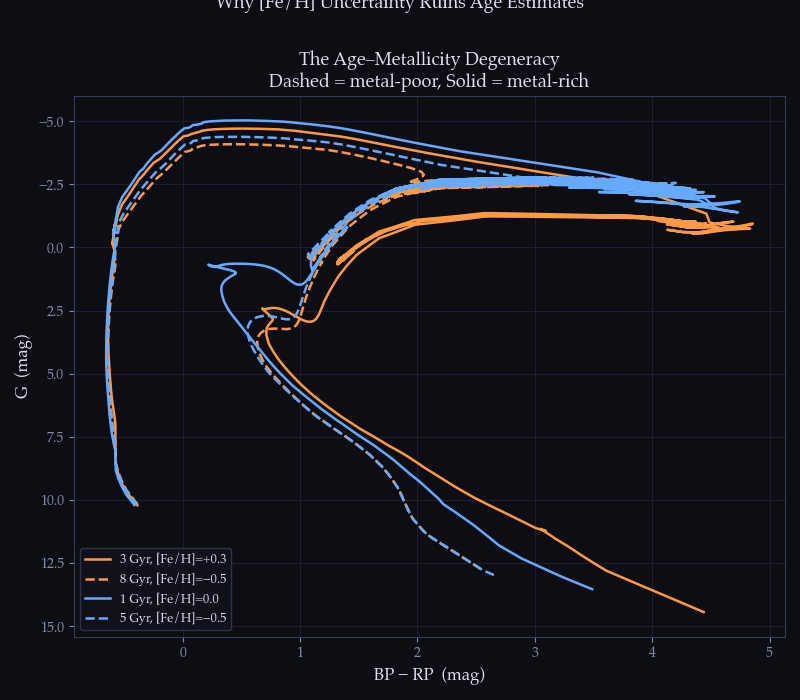


Key takeaway:
A 3 Gyr metal-rich star and an 8 Gyr metal-poor star can occupy nearly
the same position in the CMD. This is why the pipeline treats [Fe/H] as
a free parameter with a tight prior — if metallicity drifts, the fitted
age drifts with it.



In [5]:
# Why metallicity ruins age estimates
# Shows the degeneracy: an old metal-poor star can look like
# a younger metal-rich star in color-magnitude space.

fig, ax = plt.subplots(figsize=(8, 7))
fig.patch.set_facecolor("#0d0d14")
ax.set_facecolor("#0d0d14")
for spine in ax.spines.values():
    spine.set_edgecolor("#3a3a55")
ax.tick_params(colors="#8888aa")
ax.grid(True, color="#1e1e30", linewidth=0.8)

# pairs that look similar in CMD space despite different true ages
degenerate_pairs = [
    (3.0,  0.3,  "#ff9944", "3 Gyr, [Fe/H]=+0.3"),
    (8.0, -0.5,  "#ff9944", "8 Gyr, [Fe/H]=−0.5"),  # same color as above
    (1.0,  0.0,  "#66aaff", "1 Gyr, [Fe/H]=0.0"),
    (5.0, -0.5,  "#66aaff", "5 Gyr, [Fe/H]=−0.5"),  # similar to above
]

for age, feh, color, label in degenerate_pairs:
    iso = get_iso(age, feh)
    if iso is None:
        continue
    ls = "-" if feh >= 0 else "--"
    ax.plot(iso["BP_mag"] - iso["RP_mag"], iso["G_mag"],
            color=color, lw=1.8, ls=ls, label=label)

ax.invert_yaxis()
ax.set_xlabel("BP − RP  (mag)")
ax.set_ylabel("G  (mag)")
ax.set_title("The Age–Metallicity Degeneracy\n"
             "Dashed = metal-poor, Solid = metal-rich",
             color="#e0e0f0")
ax.legend(fontsize=9, labelcolor="#e0e0f0")

fig.suptitle("Why [Fe/H] Uncertainty Ruins Age Estimates",
             fontsize=13, color="#e0e0f0", y=1.01, fontfamily="serif")
plt.tight_layout()
plt.savefig("grid_explorer_degeneracy.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("""
Key takeaway:
A 3 Gyr metal-rich star and an 8 Gyr metal-poor star can occupy nearly
the same position in the CMD. This is why the pipeline treats [Fe/H] as
a free parameter with a tight prior — if metallicity drifts, the fitted
age drifts with it.
""")